# **DEEP LEARNING INTRODUCTION**
___

**MATERIALS**
1. [Penerapan Multilayer Perceptron (MLP): Penjelasan dan Studi Kasus](#1)
    - [Konsep MLP](#11)
    - [Studi Kasus](#12)
2. [Penerapan Convolutional Neural Netowrk (CNN): Penjelasan dan Studi Kasus](#2)
    - [Konsep CNN](#21)
    - [Studi Kasus](#22)
3. [Penerapan Transfer Learning: Penjelasan dan Studi Kasus](#3)
    - [Konsep Transfer Learning](#31)
    - [Studi Kasus](#32)

---

**SOURCES**
1. Tensorflow Keras:
    - Ver. 2.12.0
    - Documentations: https://www.tensorflow.org/versions/r2.12/api_docs/python/tf
    - Github: https://github.com/tensorflow/tensorflow
2. Datasets
    - CIFAR10: https://www.cs.toronto.edu/~kriz/cifar.html
    - MNIST: https://www.tensorflow.org/datasets/catalog/mnist
    - Tiny ImageNet: https://git.ece.iastate.edu/teaching/cpre487_587/tiny-imagenet-tfds (as pretrained weight)

---

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2" # Ignore TensorFlow INFO and WARNING messages

import tensorflow as tf
from tensorflow.python.client import device_lib

GLOBAL_SEED = 42
tf.keras.utils.set_random_seed(GLOBAL_SEED) # Set tf global random seed
tf.config.experimental.enable_op_determinism()

# Check for GPU availability
gpus = tf.config.list_physical_devices("GPU")
print(f"GPU Available: {bool(gpus)}")

if gpus:
    # !nvidia-smi
    tf.config.set_visible_devices(gpus, 'GPU')
    usage_devices = [gpu.name for gpu in tf.config.list_logical_devices('GPU')]

    devices = device_lib.list_local_devices()
    print("\nUsage Devices:")
    for dev in devices:
        if dev.name in usage_devices and dev.device_type == "GPU":
            print("Device:", dev.name)
            print("Description:", dev.physical_device_desc)


2026-02-18 16:40:10.632699: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-18 16:40:10.650053: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-18 16:40:10.654755: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


GPU Available: True

Usage Devices:
Device: /device:GPU:0
Description: device: 0, name: NVIDIA GeForce RTX 5060 Ti, pci bus id: 0000:01:00.0, compute capability: 12.0


I0000 00:00:1771432812.721765   35791 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1771432812.864910   35791 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1771432812.864974   35791 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1771432812.868401   35791 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1771432812.868452   35791 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:0

In [2]:
import numpy as np
from matplotlib import pyplot as plt

import tensorflow_datasets as tfds
from keras.callbacks import EarlyStopping, ModelCheckpoint
from keras.datasets import mnist, cifar10
import keras

os.makedirs("/app/datasets", exist_ok=True)
os.makedirs("/app/checkpoints", exist_ok=True)

DATA_PATH = "/app/datasets"
CKPT_PATH = "/app/checkpoints"

In [3]:
# Utility functions

# Function to generate training and validation plots for loss and accuracy
def generate_plot(result):
    plt.figure(figsize=(12, 4))
    for idx, metric in enumerate(["Loss", "Accuracy"]):
        plt.subplot(1, 2, idx+1)
        plt.plot(result.history[metric.lower()], label=f'Training {metric}')
        plt.plot(result.history[f'val_{metric.lower()}'], label=f'Validation {metric}')
        plt.xlabel('Epoch')
        plt.ylabel(f'{metric}')
        plt.legend()
        plt.title(f'{metric} Over Time')
    plt.show()

# Function to visualize model predictions with confidence scores
def plot_predictions(model, X_vis_norm, X_vis_raw, y_true, img_shape, class_names=None, cmap="gray", title="Predictions vs True Labels"):
    scores = model.predict(X_vis_norm, verbose=0)
    predictions = tf.argmax(scores, axis=1).numpy()

    n = len(X_vis_norm)
    fig, axes = plt.subplots(1, n, figsize=(3*n, 4))
    if n == 1:
        axes = [axes]

    for i in range(n):
        axes[i].imshow(X_vis_raw[i].reshape(img_shape), cmap=cmap)

        pred_id = predictions[i]
        true_id = int(y_true[i])

        # Convert to names if provided
        if class_names is not None:
            pred_label = class_names[pred_id]
            true_label = class_names[true_id]
        else:
            pred_label = pred_id
            true_label = true_id

        conf = scores[i][pred_id] * 100

        axes[i].set_title(
            f"Conf: {conf:.2f}%\n"
            f"Pred: {pred_label}\n"
            f"True: {true_label}"
        )
        axes[i].axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


#function to visualize random samples from the dataset
def visualize_data(x, y, title, n=6):
    idx = np.random.choice(len(x), n, replace=False)

    plt.figure(figsize=(10,4))
    for i, j in enumerate(idx):
        plt.subplot(2,6,i+1)
        plt.imshow(x[j], cmap="gray")
        plt.title(int(y[j]))
        plt.axis("off")
    plt.suptitle(title)
    plt.show()
    
#function to visualize random samples from the dataset with class names
def class_distribution(y_or_ds, name, num_classes=10):
    if isinstance(y_or_ds, tf.data.Dataset):
        y_list = []
        for _, label in y_or_ds:
            y_list.append(int(label.numpy()))
        y = np.array(y_list)
    else:
        y = np.array(y_or_ds).reshape(-1).astype(int)

    counts = np.bincount(y, minlength=num_classes)
    total = len(y)

    print(f"\n{name} class distribution:")
    for i in range(num_classes):
        print(f"Class {i}: {counts[i]:5d}  ({counts[i]/total:.3f})")


<a id="1"></a>
## **1. Penerapan Multilayer Perceptron (MLP): Penjelasan dan Studi Kasus**
---

<a id=11></a>
### **1.1 Konsep MLP**

Multilayer Perceptron (MLP) adalah salah satu fundamental dari Deep Learning.
Sebagaimana namanya, MLP terdiri dari banyak layer neuron atau perceptron. MLP
biasanya memiliki tiga jenis layer: input layer, hidden layer, dan output layer.

__Struktur MLP__

1. __Input Layer:__ Layer ini terdiri dari neuron yang merepresentasikan setiap fitur dalam data. Misalnya, jika kamu memiliki data gambar 28x28 pixel, maka input layer akan memiliki 784 neuron.

2. __Hidden Layer:__ Hidden layer berisi sejumlah neuron yang memproses informasi dari input layer. MLP bisa memiliki lebih dari satu hidden layer, inilah yang membuatnya menjadi "Deep" Neural Network.

3. __Output Layer:__ Layer ini berisi neuron yang merepresentasikan kelas atau nilai output dari masalah kita.

Setiap neuron dalam MLP dihubungkan dengan semua neuron di layer sebelum dan
sesudahnya. Bobot dan bias dikaitkan dengan setiap koneksi ini, dan ini yang diadjust
selama proses training.

__Fungsi Aktivasi dalam MLP__

MLP biasanya menggunakan fungsi aktivasi non-linear di neuronnya. Ini memungkinkan
MLP untuk memodelkan hubungan kompleks dan non-linear antara fitur. Fungsi aktivasi
yang paling umum digunakan adalah ReLU, tetapi yang lain seperti sigmoid atau tanh juga
dapat digunakan.

__Proses Training MLP__

MLP dilatih menggunakan metode yang disebut backpropagation dan algoritma optimasi
seperti Stochastic Gradient Descent (SGD) atau Adam. Proses training mencakup forward
pass di mana menghasilkan prediksi, lalu menghitung loss berdasarkan input saat ini, backward pass di mana menghitung gradient loss pakai backpropagation, dan optimasi di mana bobot dan bias diperbarui berdasarkan gradient yang dihasilkan.

<a id=12></a>
### **1.2 Studi Kasus**
Misalnya, kita ingin membuat MLP menggunakan library keras dari TensorFlow untuk mengklasifikasi objek dan digit. Berikut adalah kode yang kita perlukan:

#### MLP MNIST Digit classifier 

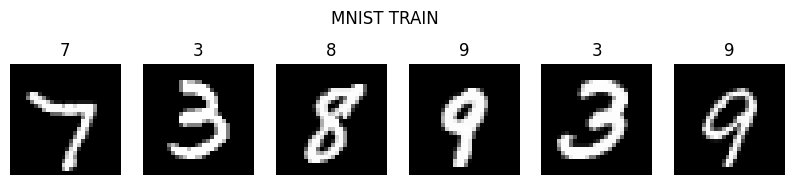

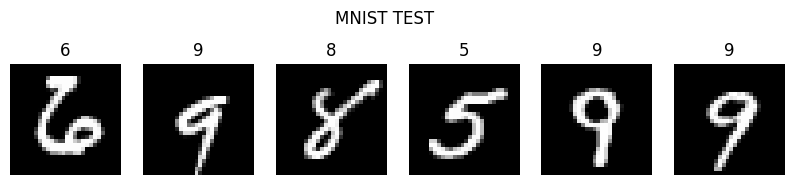

In [4]:
(X_train_MNIST, y_train_MNIST), (X_test_MNIST, y_test_MNIST) = mnist.load_data()

visualize_data(X_train_MNIST, y_train_MNIST, "MNIST TRAIN")
visualize_data(X_test_MNIST,  y_test_MNIST,  "MNIST TEST")

In [5]:
class_distribution(y_train_MNIST, "TRAIN")
class_distribution(y_test_MNIST,  "TEST")


TRAIN class distribution:
Class 0:  5923  (0.099)
Class 1:  6742  (0.112)
Class 2:  5958  (0.099)
Class 3:  6131  (0.102)
Class 4:  5842  (0.097)
Class 5:  5421  (0.090)
Class 6:  5918  (0.099)
Class 7:  6265  (0.104)
Class 8:  5851  (0.098)
Class 9:  5949  (0.099)

TEST class distribution:
Class 0:   980  (0.098)
Class 1:  1135  (0.114)
Class 2:  1032  (0.103)
Class 3:  1010  (0.101)
Class 4:   982  (0.098)
Class 5:   892  (0.089)
Class 6:   958  (0.096)
Class 7:  1028  (0.103)
Class 8:   974  (0.097)
Class 9:  1009  (0.101)


In [6]:
VAL_SIZE_MNIST=10000
BATCH_SIZE_MNIST_MLP = 64
RANDOM_SEED_MNIST=67

np.random.seed(RANDOM_SEED_MNIST)          # make it reproducible
perm = np.random.permutation(len(X_train_MNIST))  # shuffled indices

X_train_MNIST = X_train_MNIST[perm]
y_train_MNIST = y_train_MNIST[perm]


X_val_MNIST = X_train_MNIST[-VAL_SIZE_MNIST:]
y_val_MNIST = y_train_MNIST[-VAL_SIZE_MNIST:]

X_train_MNIST = X_train_MNIST[:-VAL_SIZE_MNIST]
y_train_MNIST = y_train_MNIST[:-VAL_SIZE_MNIST]

print("Train:", X_train_MNIST.shape, y_train_MNIST.shape)
print("Val  :", X_val_MNIST.shape, y_val_MNIST.shape)
print("Test :", X_test_MNIST.shape, y_test_MNIST.shape)

Train: (50000, 28, 28) (50000,)
Val  : (10000, 28, 28) (10000,)
Test : (10000, 28, 28) (10000,)


In [7]:
X_train_MNIST = X_train_MNIST.astype(np.float32) / 255.0
X_val_MNIST   = X_val_MNIST.astype(np.float32) / 255.0
X_test_MNIST  = X_test_MNIST.astype(np.float32) / 255.0

y_train_MNIST = y_train_MNIST.astype(np.int32)
y_val_MNIST   = y_val_MNIST.astype(np.int32)
y_test_MNIST  = y_test_MNIST.astype(np.int32)

In [8]:
mlp_digit_classifier_model = keras.Sequential([
    keras.layers.Input(shape=(28,28)),
    keras.layers.Flatten(), #the same as reshapeing to (784,)
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(10, activation='softmax'),
], name="mlp_digit_classifier")

mlp_digit_classifier_model_initial_weights = mlp_digit_classifier_model.get_weights()
mlp_digit_classifier_model.summary()

Model: "mlp_digit_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,938 (409.91 KB)

 Trainable params: 104,938 (409.91 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
mlp_digit_classifier_model.set_weights(mlp_digit_classifier_model_initial_weights)

mlp_digit_classifier_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

mlp_digit_classifier_model_early_stopping = EarlyStopping(monitor='val_loss', patience=8, verbose=1, mode='min')
mlp_digit_classifier_model_mcp = ModelCheckpoint(f'{CKPT_PATH}/mlp_digit_classifier.keras', save_best_only=True, verbose=1, monitor='val_loss')

result = mlp_digit_classifier_model.fit(
    X_train_MNIST,               
    y_train_MNIST,               
    epochs=30, 
    batch_size=BATCH_SIZE_MNIST_MLP,
    validation_data=(X_val_MNIST, y_val_MNIST), 
    callbacks=[mlp_digit_classifier_model_early_stopping, mlp_digit_classifier_model_mcp],
)


Epoch 1/30


I0000 00:00:1771432815.930329   35977 service.cc:146] XLA service 0x7aef040030b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771432815.930372   35977 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 5060 Ti, Compute Capability 12.0
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


  1/782 ━━━━━━━━━━━━━━━━━━━━ 22:39 2s/step - accuracy: 0.1250 - loss: 2.4260

I0000 00:00:1771432816.655630   35977 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


769/782 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8267 - loss: 0.5950

...

782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8280 - loss: 0.5906

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)



Epoch 1: val_loss improved from inf to 0.18232, saving model to /app/checkpoints/mlp_digit_classifier.keras
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8281 - loss: 0.5902 - val_accuracy: 0.9477 - val_loss: 0.1823
Epoch 2/30
 15/782 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9515 - loss: 0.1662  

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


773/782 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9541 - loss: 0.1547
Epoch 2: val_loss improved from 0.18232 to 0.13600, saving model to /app/checkpoints/mlp_digit_classifier.keras
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9542 - loss: 0.1545 - val_accuracy: 0.9603 - val_loss: 0.1360
Epoch 3/30
778/782 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9689 - loss: 0.1042
Epoch 3: val_loss improved from 0.13600 to 0.11411, saving model to /app/checkpoints/mlp_digit_classifier.keras
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9689 - loss: 0.1041 - val_accuracy: 0.9669 - val_loss: 0.1141
Epoch 4/30
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9776 - loss: 0.0764
Epoch 4: val_loss improved from 0.11411 to 0.10460, saving model to /app/checkpoints/mlp_digit_classifier.keras
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9776 - loss: 0.0764 - val_accuracy: 0.9691 - val_loss: 0.1046
Epoch 5/30
777/782 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.

In [10]:
mlp_digit_classifier_model.load_weights(f'{CKPT_PATH}/mlp_digit_classifier.keras')

test_loss, test_acc = mlp_digit_classifier_model.evaluate(X_test_MNIST, y_test_MNIST, verbose=0)

print(f"Test Accuracy: {test_acc * 100:.2f}%")


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


Test Accuracy: 97.38%


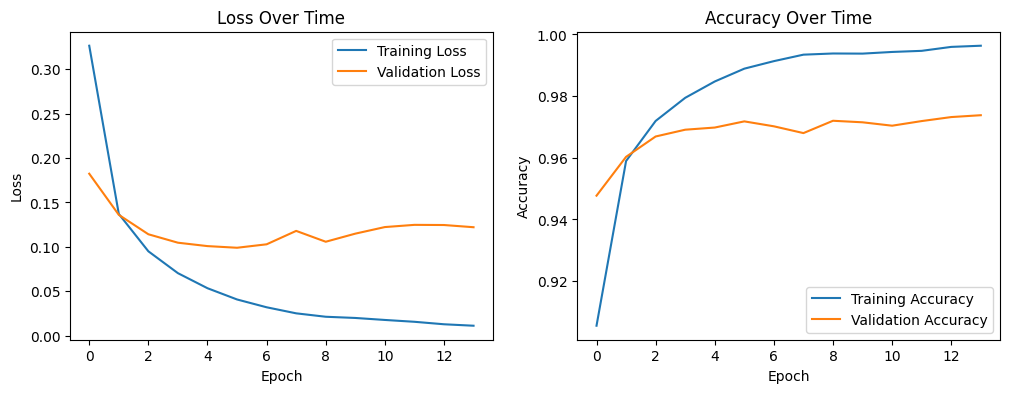

In [11]:
generate_plot(result)

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


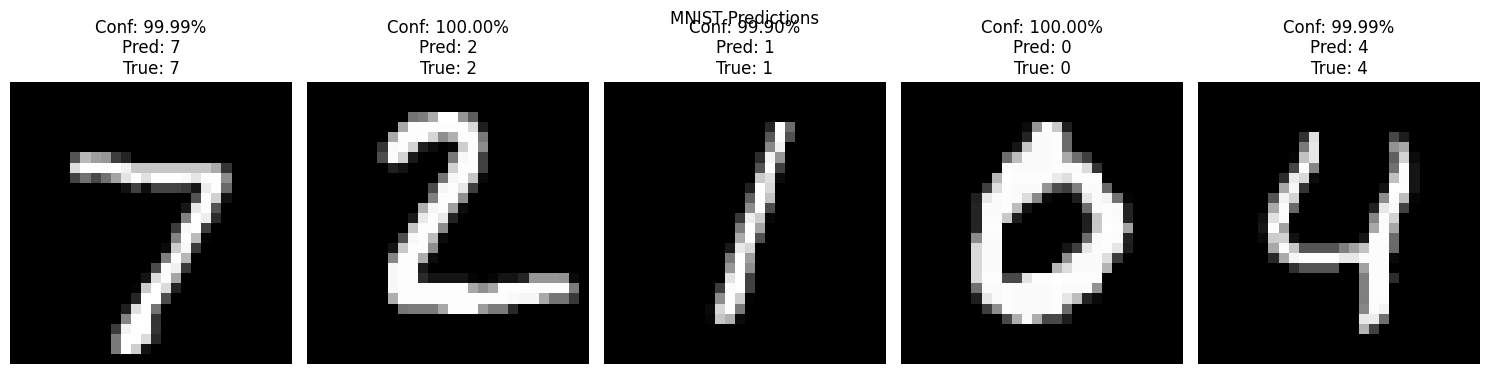

In [12]:
# Load best weights
mlp_digit_classifier_model_inference=keras.models.load_model(f"{CKPT_PATH}/mlp_digit_classifier.keras")

# Take 5 samples
X_vis = X_test_MNIST[:5]
y_true = y_test_MNIST[:5]

plot_predictions(
    mlp_digit_classifier_model_inference,
    X_vis,
    X_vis,
    y_true,
    img_shape=(28,28),
    title="MNIST Predictions"
)

<a id="2"></a>
## **2. Penerapan Convolutional Neural Netowrk (CNN): Penjelasan dan Studi Kasus**
---

<a id=21></a>
### **2.1 Konsep CNN**

Convolutional Neural Network (CNN) adalah jenis khusus dari neural networks yang
dirancang khusus untuk memproses data dengan struktur grid seperti gambar. CNN telah
sukses besar dalam berbagai aplikasi pengenalan gambar dan video.

__Struktur CNN__
1. __Input Layer:__ Layer ini terdiri dari neuron yang merepresentasikan setiap input fitur dalam data. Umumnya berupa gambar berbentuk N (Total / Batch image), H (Height), W (Width), C (Channel).
2. __Convolutional Layer:__ Layer konvolusi adalah elemen inti dari CNN. Dalam layer ini, beberapa filter digunakan untuk melakukan operasi konvolusi pada input. Hasil dari operasi ini disebut feature map atau activation map.
3. __Pooling Layer:__ Pooling layer bertujuan untuk mengurangi dimensionalitas data. Ada berbagai teknik pooling, termasuk max pooling, average pooling, dan sum pooling.
4. __Fully Connected Layer:__ Fully connected layer menghubungkan setiap neuron di layer sebelumnya ke setiap neuron di layer berikutnya, mirip dengan apa yang kita lihat di MLP. Biasanya, fully connected layer ditempatkan di akhir arsitektur CNN, dan bertugas untuk menghasilkan prediksi akhir model.

__Fungsi Aktivasi dalam CNN__

ReLU (Rectified Linear Unit) adalah fungsi aktivasi yang paling sering digunakan dalam
CNN. Fungsi ini mampu mempercepat konvergensi jaringan neural dibandingkan dengan
sigmoid atau tanh.

__Proses Training CNN__

Proses pelatihan CNN serupa dengan MLP. Kami menggunakan metode seperti
backpropagation dan algoritma optimasi seperti Adam atau SGD untuk melatih model kami.
Kita menghitung loss dengan fungsi loss seperti cross-entropy, dan mengupdate
bobot dan bias berdasarkan gradien loss dari proses backward pass.

<a id=22></a>
### **2.2 Studi Kasus**
Alih-alih menggunakan MLP yang hanya memiliki layer sederhana, kita akan coba membuat model CNN pakai library keras dari TensorFlow untuk mengklasifikasi objek dan digit dengan hasil prediksi yang lebih baik. Berikut adalah kode yang kita perlukan:

#### CNN MNIST Digit classifier 

In [13]:
BATCH_SIZE_MNIST_CNN=64

In [14]:
# Create model
cnn_digit_classifier_model = keras.Sequential([
    keras.Input(shape=(28,28,1)),
    # Block 1
    keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
    keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
    keras.layers.MaxPool2D(2),
    # Block 2
    keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
    keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
    keras.layers.MaxPool2D(2),
    # Block 3
    keras.layers.Conv2D(128, 3, padding="same", activation="relu"),
    keras.layers.Conv2D(128, 3, padding="same", activation="relu"),
    keras.layers.MaxPool2D(2),
    # Classifier
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
], name="cnn_digit_classifier")

cnn_digit_classifier_model_initial_weights = cnn_digit_classifier_model.get_weights()
cnn_digit_classifier_model.summary()

Model: "cnn_digit_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 435,306 (1.66 MB)

 Trainable params: 435,306 (1.66 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
cnn_digit_classifier_model.set_weights(cnn_digit_classifier_model_initial_weights)

cnn_digit_classifier_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
    ,jit_compile=False
)

In [16]:

# Define callbacks
cnn_digit_classifier_model_early_stopping = EarlyStopping(monitor='val_loss', patience=8, verbose=1, mode='min')
cnn_digit_classifier_model_mcp = ModelCheckpoint(f'{CKPT_PATH}/cnn_digit_classifier.keras', save_best_only=True, verbose=1, monitor='val_loss')

# Train model with history tracking
result = cnn_digit_classifier_model.fit(
    X_train_MNIST,               # first argument: features
    y_train_MNIST,               # second argument: labels
    epochs=30, 
    batch_size=BATCH_SIZE_MNIST_CNN,
    validation_data=(X_val_MNIST, y_val_MNIST), 
    callbacks=[cnn_digit_classifier_model_early_stopping, cnn_digit_classifier_model_mcp],
)

Epoch 1/30


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

  8/782 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.1174 - loss: 2.2774

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
W0000 00:00:1771432866.926287   35975 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1771432866.931216   35975 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1771432866.933398   35975 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1771432866.934610   35975 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1771432866.936544   35975 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1771432866.937935   35975 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1771432866.939817   35975 gpu_timer.cc:114] Skipping

782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8769 - loss: 0.3696

...

782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9849 - loss: 0.0494

W0000 00:00:1771432889.052423   35972 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1771432889.053924   35972 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1771432889.055567   35972 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1771432889.056465   35972 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1771432889.057419   35972 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1771432889.058507   35972 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1771432889.063983   35976 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1771432889.065265   35976 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1771432889.066664   35976 gp


Epoch 2: val_loss improved from 0.06444 to 0.04714, saving model to /app/checkpoints/cnn_digit_classifier.keras
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9849 - loss: 0.0494 - val_accuracy: 0.9846 - val_loss: 0.0471
Epoch 3/30
  5/782 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.9960 - loss: 0.0146

W0000 00:00:1771432889.704528   35976 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1771432889.705995   35976 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1771432889.707208   35976 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1771432889.708271   35976 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1771432889.709345   35976 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1771432889.710545   35976 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced


779/782 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9903 - loss: 0.0313
Epoch 3: val_loss did not improve from 0.04714
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9903 - loss: 0.0313 - val_accuracy: 0.9826 - val_loss: 0.0575
Epoch 4/30
780/782 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9919 - loss: 0.0255
Epoch 4: val_loss improved from 0.04714 to 0.03829, saving model to /app/checkpoints/cnn_digit_classifier.keras
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9919 - loss: 0.0255 - val_accuracy: 0.9877 - val_loss: 0.0383
Epoch 5/30
779/782 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9927 - loss: 0.0216
Epoch 5: val_loss did not improve from 0.03829
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9927 - loss: 0.0216 - val_accuracy: 0.9870 - val_loss: 0.0503
Epoch 6/30
780/782 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9944 - loss: 0.0180
Epoch 6: val_loss did not improve from 0.03829
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy

In [17]:
cnn_digit_classifier_model.load_weights(f'{CKPT_PATH}/cnn_digit_classifier.keras')
test_loss, test_acc = cnn_digit_classifier_model.evaluate(X_test_MNIST, y_test_MNIST, verbose=0)

print(f"Test Accuracy: {test_acc * 100:.2f}%")

W0000 00:00:1771433009.868078   35978 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1771433009.869326   35978 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1771433009.870244   35978 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1771433009.871318   35978 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1771433009.872392   35978 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1771433009.873869   35978 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced


Test Accuracy: 98.97%


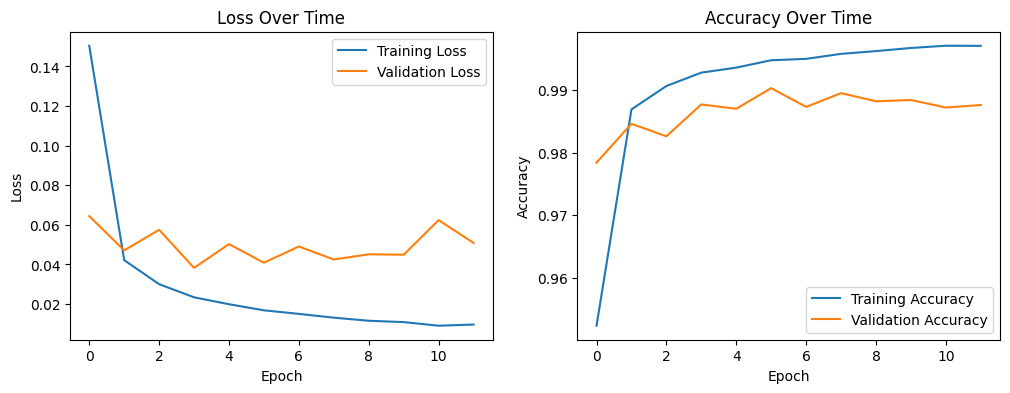

In [18]:
generate_plot(result)

W0000 00:00:1771433011.540064   35974 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1771433011.540887   35974 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1771433011.541620   35974 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1771433011.542289   35974 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1771433011.542927   35974 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1771433011.543602   35974 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced


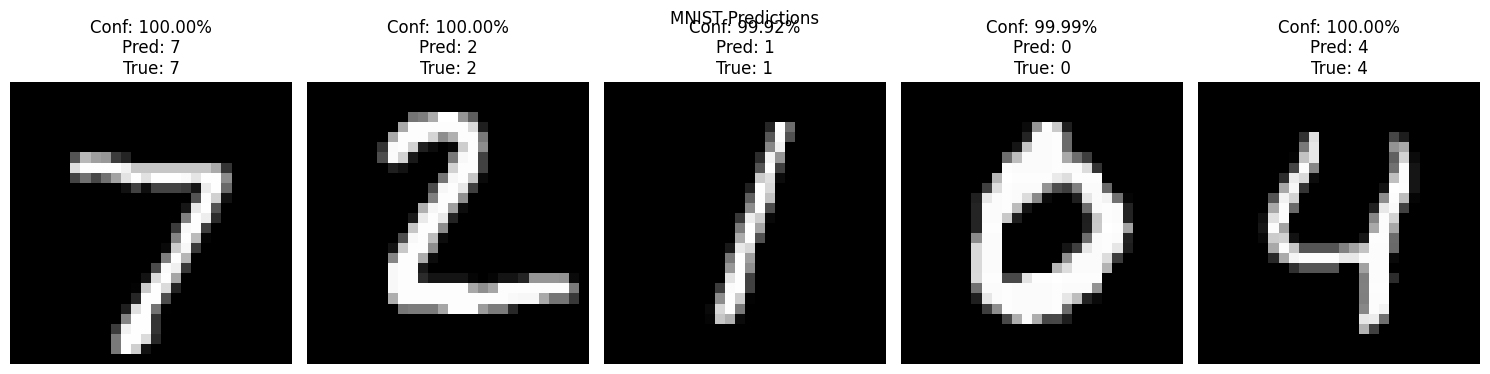

In [19]:
# Take 5 samples
cnn_digit_classifier_inference_model=keras.models.load_model(f"{CKPT_PATH}/cnn_digit_classifier.keras")

X_vis = X_test_MNIST[:5]
y_true = y_test_MNIST[:5]

plot_predictions(
    cnn_digit_classifier_inference_model,
    X_vis,
    X_vis,
    y_true,
    img_shape=(28,28),
    title="MNIST Predictions"
)

## Dataset: CIFAR-10

#### MLP CIFAR object classifier 

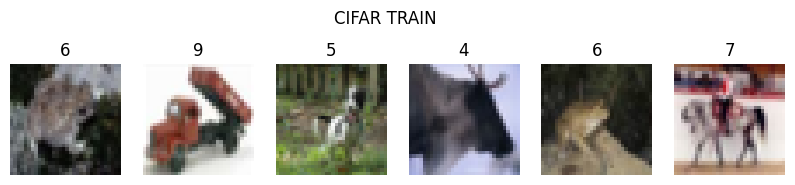

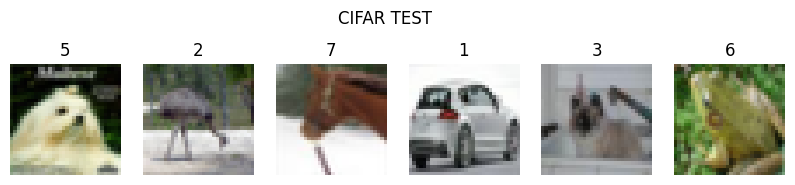

In [20]:
(train_ds_CIFAR, test_ds_CIFAR), info = tfds.load(
    "cifar10",
    split=["train", "test"],
    as_supervised=True,
    with_info=True,
    data_dir="/app/datasets/tfds",
)
CIFAR_CLASS = info.features["label"].names
X_vis_train_CIFAR = []
y_vis_train_CIFAR = []
X_vis_test_CIFAR = []
y_vis_test_CIFAR = []
for img, label in train_ds_CIFAR.take(10):
    X_vis_train_CIFAR.append(img)
    y_vis_train_CIFAR.append(label)
for img, label in test_ds_CIFAR.take(10):
    X_vis_test_CIFAR.append(img)
    y_vis_test_CIFAR.append(label)
visualize_data(X_vis_train_CIFAR, y_vis_train_CIFAR, "CIFAR TRAIN")
visualize_data(X_vis_test_CIFAR, y_vis_test_CIFAR, "CIFAR TEST")

In [21]:
class_distribution(train_ds_CIFAR, "TRAIN")
class_distribution(test_ds_CIFAR,  "TEST")


TRAIN class distribution:
Class 0:  5000  (0.100)
Class 1:  5000  (0.100)
Class 2:  5000  (0.100)
Class 3:  5000  (0.100)
Class 4:  5000  (0.100)
Class 5:  5000  (0.100)
Class 6:  5000  (0.100)
Class 7:  5000  (0.100)
Class 8:  5000  (0.100)
Class 9:  5000  (0.100)

TEST class distribution:
Class 0:  1000  (0.100)
Class 1:  1000  (0.100)
Class 2:  1000  (0.100)
Class 3:  1000  (0.100)
Class 4:  1000  (0.100)
Class 5:  1000  (0.100)
Class 6:  1000  (0.100)
Class 7:  1000  (0.100)
Class 8:  1000  (0.100)
Class 9:  1000  (0.100)


In [22]:
VAL_SIZE_CIFAR=10000
BATCH_SIZE_CIFAR=64
RANDOM_SEED_CIFAR=67


train_ds_CIFAR = train_ds_CIFAR.shuffle(10000, seed=RANDOM_SEED_CIFAR, reshuffle_each_iteration=False)

# Split
val_ds_CIFAR   = train_ds_CIFAR.take(VAL_SIZE_CIFAR)
train_ds_CIFAR = train_ds_CIFAR.skip(VAL_SIZE_CIFAR)

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

In [23]:
def preprocess_ds_CIFAR(x, y):
    x_new = tf.cast(x, tf.float32) / 255.0
    y_new = tf.cast(y, tf.int32)
    print(f"Change shape from {x.shape} to {x_new.shape}")
    return x_new, y_new

# train_ds_CIFAR = tf.data.Dataset.from_tensor_slices((X_train_CIFAR, y_train_CIFAR))
train_ds_CIFAR = train_ds_CIFAR.map(preprocess_ds_CIFAR, num_parallel_calls=tf.data.AUTOTUNE)
train_ds_CIFAR = train_ds_CIFAR.batch(BATCH_SIZE_CIFAR)
train_ds_CIFAR = train_ds_CIFAR.prefetch(tf.data.AUTOTUNE)

# val_ds_CIFAR = tf.data.Dataset.from_tensor_slices((X_val_CIFAR, y_val_CIFAR))
val_ds_CIFAR = val_ds_CIFAR.map(preprocess_ds_CIFAR, num_parallel_calls=tf.data.AUTOTUNE)
val_ds_CIFAR = val_ds_CIFAR.batch(BATCH_SIZE_CIFAR)
val_ds_CIFAR = val_ds_CIFAR.prefetch(tf.data.AUTOTUNE)

# test_ds_CIFAR = tf.data.Dataset.from_tensor_slices((X_test_CIFAR, y_test_CIFAR))
test_ds_CIFAR = test_ds_CIFAR.map(preprocess_ds_CIFAR, num_parallel_calls=tf.data.AUTOTUNE)
test_ds_CIFAR = test_ds_CIFAR.batch(BATCH_SIZE_CIFAR)
test_ds_CIFAR = test_ds_CIFAR.prefetch(tf.data.AUTOTUNE)

Change shape from (32, 32, 3) to (32, 32, 3)
Change shape from (32, 32, 3) to (32, 32, 3)
Change shape from (32, 32, 3) to (32, 32, 3)


In [24]:
# Create model
mlp_object_classifier_model = keras.Sequential([
    keras.layers.Input(shape=(32,32,3)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(10, activation='softmax'),
], name="mlp_object_classifier")
mlp_object_classifier_model_initial_weights = mlp_object_classifier_model.get_weights()
mlp_object_classifier_model.summary()


Model: "mlp_object_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 397,802 (1.52 MB)

 Trainable params: 397,802 (1.52 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:

mlp_object_classifier_model.set_weights(mlp_object_classifier_model_initial_weights)

mlp_object_classifier_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
    jit_compile=False
)
mlp_object_classifier_model_early_stopping = EarlyStopping(monitor='val_loss', patience=8, verbose=1, mode='min')
mlp_object_classifier_model_mcp = ModelCheckpoint(f'{CKPT_PATH}/mlp_object_classifier.keras', save_best_only=True, verbose=1, monitor='val_loss')

result = mlp_object_classifier_model.fit(
    train_ds_CIFAR,
    epochs=30, 
    validation_data=val_ds_CIFAR, 
    callbacks=[mlp_object_classifier_model_early_stopping, mlp_object_classifier_model_mcp],
)

Epoch 1/30
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1996 - loss: 2.1640
Epoch 1: val_loss improved from inf to 1.93095, saving model to /app/checkpoints/mlp_object_classifier.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.1998 - loss: 2.1636 - val_accuracy: 0.2909 - val_loss: 1.9310
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3355 - loss: 1.8373
Epoch 2: val_loss improved from 1.93095 to 1.76040, saving model to /app/checkpoints/mlp_object_classifier.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.3355 - loss: 1.8373 - val_accuracy: 0.3669 - val_loss: 1.7604
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3773 - loss: 1.7340
Epoch 3: val_loss improved from 1.76040 to 1.75017, saving model to /app/checkpoints/mlp_object_classifier.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.3773 - loss: 1.7340 - val_accuracy: 0.3789 - val_loss: 1.7502
Epoch 4/30
621/625 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step -

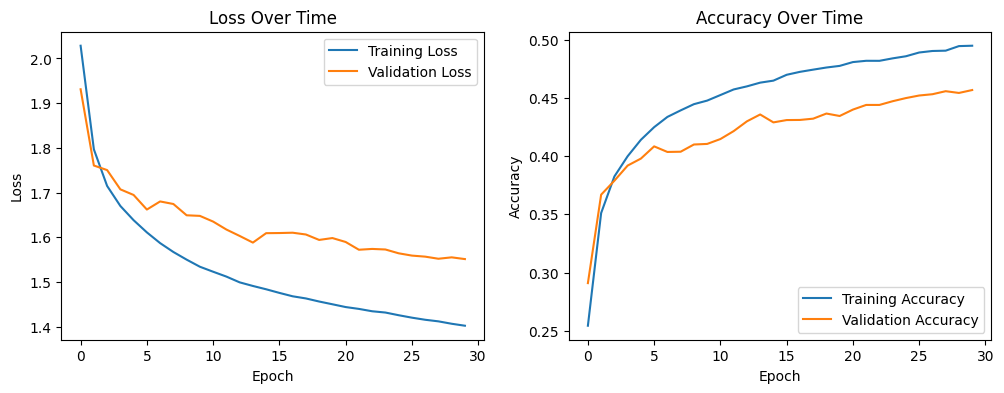

In [26]:
# Plot training history
generate_plot(result)

In [27]:
# Evaluate model
mlp_object_classifier_model.load_weights(f'{CKPT_PATH}/mlp_object_classifier.keras')
test_loss_CIFAR, test_acc_CIFAR = mlp_object_classifier_model.evaluate(test_ds_CIFAR)
print(f"Test Accuracy: {test_acc_CIFAR * 100:.2f}%")


157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4571 - loss: 1.5064
Test Accuracy: 45.33%


(5, 32, 32, 3)
(5, 1)


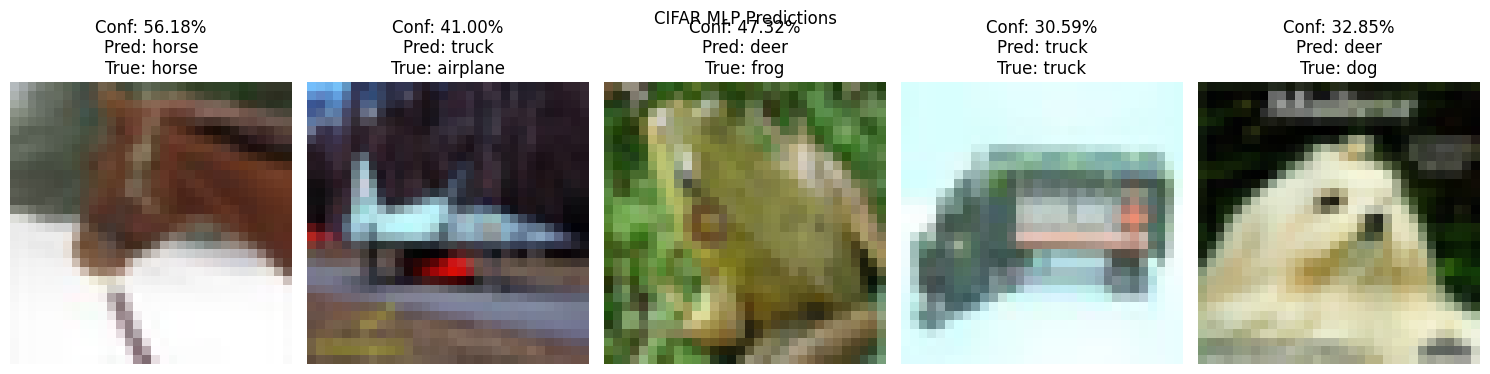

In [28]:
mlp_object_classifier_inference_model=keras.models.load_model(f"{CKPT_PATH}/mlp_object_classifier.keras")

num_samples = 5
X_vis, y_true = [], []

for img, lbl in test_ds_CIFAR.unbatch().take(num_samples):
    X_vis.append(img)
    y_true.append([lbl])

X_vis = tf.stack(X_vis)
X_vis_norm = tf.cast(X_vis, tf.float32)
y_true = tf.stack(y_true)
print(X_vis.shape)
print(y_true.shape)

# Now plot
plot_predictions(
    mlp_object_classifier_inference_model,
    X_vis_norm,
    X_vis.numpy(),
    y_true,
    class_names=CIFAR_CLASS,
    img_shape=(32,32,3),
    title="CIFAR MLP Predictions"
)

#### CNN CIFAR object classifier 1

In [29]:
cnn_object_classifier_model = keras.Sequential([
    keras.Input(shape=(32,32,3)),

    # Block 1
    keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
    keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
    keras.layers.MaxPool2D(2),
    # Block 2
    keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
    keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
    keras.layers.MaxPool2D(2),
    # Block 3
    keras.layers.Conv2D(128, 3, padding="same", activation="relu"),
    keras.layers.Conv2D(128, 3, padding="same", activation="relu"),
    keras.layers.MaxPool2D(2),
    # Classifier
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
], name="cnn_object_classifier")

cnn_object_classifier_model_initial_weights = cnn_object_classifier_model.get_weights()
cnn_object_classifier_model.summary()

Model: "cnn_object_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 550,570 (2.10 MB)

 Trainable params: 550,570 (2.10 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
# Reset weights
cnn_object_classifier_model.set_weights(cnn_object_classifier_model_initial_weights)

# Compile model
cnn_object_classifier_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
    jit_compile=False
)
# Define callbacks
cnn_object_classifier_model_early_stopping = EarlyStopping(monitor='val_loss', patience=8, verbose=1, mode='min')
cnn_object_classifier_model_mcp = ModelCheckpoint(f'{CKPT_PATH}/cnn_object_classifier.keras', save_best_only=True, verbose=1, monitor='val_loss')

# Train model with history tracking
result = cnn_object_classifier_model.fit(
    train_ds_CIFAR,
    epochs=30, 
    validation_data=val_ds_CIFAR, 
    callbacks=[cnn_object_classifier_model_early_stopping, cnn_object_classifier_model_mcp],
)

Epoch 1/30
 12/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.1087 - loss: 2.3029 

W0000 00:00:1771433235.065685   35973 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1771433235.067856   35973 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1771433235.071825   35973 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1771433235.073588   35973 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1771433235.074787   35973 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1771433235.075752   35973 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1771433235.084497   35972 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1771433235.085621   35972 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1771433235.086914   35972 gp

622/625 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3052 - loss: 1.8650

W0000 00:00:1771433243.711585   35971 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1771433243.714729   35971 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1771433243.715917   35971 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1771433243.716962   35971 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1771433243.717855   35971 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1771433243.718654   35971 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced



Epoch 1: val_loss improved from inf to 1.32610, saving model to /app/checkpoints/cnn_object_classifier.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.3059 - loss: 1.8633 - val_accuracy: 0.5355 - val_loss: 1.3261
Epoch 2/30


W0000 00:00:1771433244.366509   35974 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1771433244.367377   35974 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1771433244.368107   35974 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1771433244.368747   35974 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1771433244.369444   35974 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1771433244.370179   35974 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced


621/625 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5759 - loss: 1.1763
Epoch 2: val_loss improved from 1.32610 to 1.00089, saving model to /app/checkpoints/cnn_object_classifier.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.5761 - loss: 1.1755 - val_accuracy: 0.6494 - val_loss: 1.0009
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6773 - loss: 0.9063
Epoch 3: val_loss improved from 1.00089 to 0.86611, saving model to /app/checkpoints/cnn_object_classifier.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.6773 - loss: 0.9062 - val_accuracy: 0.6990 - val_loss: 0.8661
Epoch 4/30
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7395 - loss: 0.7446
Epoch 4: val_loss did not improve from 0.86611
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.7395 - loss: 0.7445 - val_accuracy: 0.6993 - val_loss: 0.8934
Epoch 5/30
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7830 - loss: 0.6234
Epoch 5: val_loss improved from 0.86

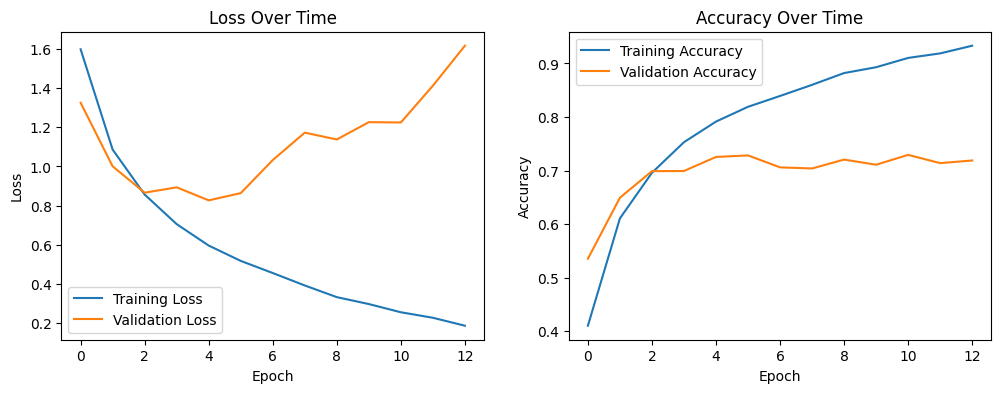

In [31]:
# Plot training history
generate_plot(result)

In [32]:
# Evaluate model
cnn_object_classifier_model.load_weights(f'{CKPT_PATH}/cnn_object_classifier.keras')
test_loss_CIFAR, test_acc_CIFAR = cnn_object_classifier_model.evaluate(test_ds_CIFAR)
print(f"Test Accuracy: {test_acc_CIFAR * 100:.2f}%")

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7331 - loss: 0.8173
Test Accuracy: 72.94%


(5, 32, 32, 3)
(5, 1)


W0000 00:00:1771433352.903039   35975 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1771433352.904320   35975 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1771433352.905238   35975 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1771433352.906086   35975 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1771433352.907001   35975 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1771433352.907872   35975 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced


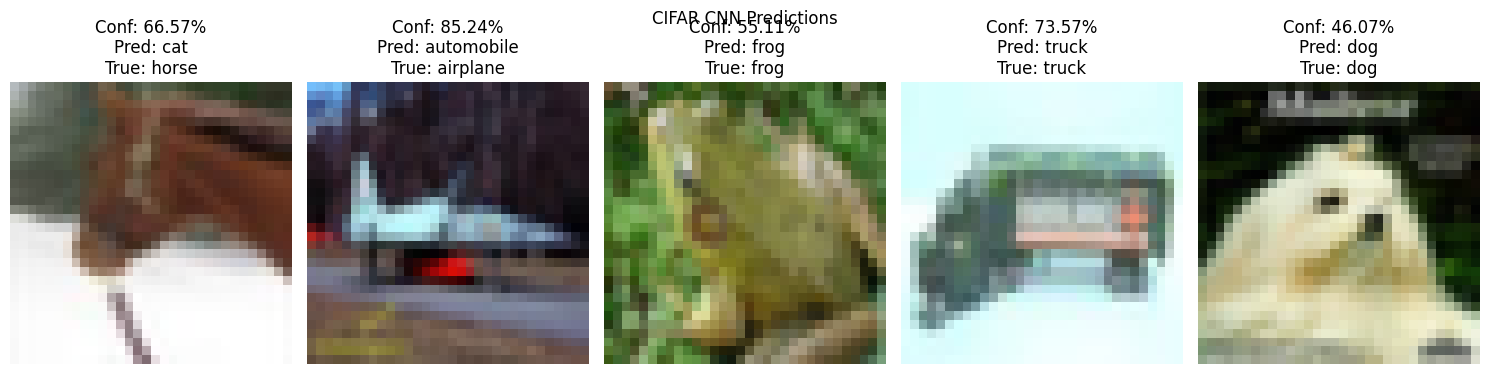

In [33]:
cnn_object_classifier_inference_model=keras.models.load_model(f"{CKPT_PATH}/cnn_object_classifier.keras")

num_samples = 5
X_vis, y_true = [], []

for img, lbl in test_ds_CIFAR.unbatch().take(num_samples):
    X_vis.append(img)
    y_true.append([lbl])

X_vis = tf.stack(X_vis)
X_vis_norm = tf.cast(X_vis, tf.float32)
y_true = tf.stack(y_true)
print(X_vis.shape)
print(y_true.shape)

# Now plot
plot_predictions(
    cnn_object_classifier_inference_model,
    X_vis_norm,
    X_vis.numpy(),
    y_true,
    img_shape=(32,32,3),
    class_names=CIFAR_CLASS,
    cmap=None,
    title="CIFAR CNN Predictions"
)


#### CNN CIFAR object classifier 2

In [34]:

cnn_object_classifier_model_v2 = keras.Sequential([
    keras.Input(shape=(32,32,3)),

    # Block 1
    keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPool2D(2),
    keras.layers.Dropout(0.2),
    # Block 2
    keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPool2D(2),
    keras.layers.Dropout(0.4),
    # Block 3
    keras.layers.Conv2D(128, 3, padding="same", activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(128, 3, padding="same", activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPool2D(2),
    keras.layers.Dropout(0.5),
    # Classifier
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(10, activation="softmax")
], name="cnn_object_classifier_v2")

cnn_object_classifier_model_v2_initial_weights = cnn_object_classifier_model_v2.get_weights()
cnn_object_classifier_model_v2.summary()

Model: "cnn_object_classifier_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 552,874 (2.11 MB)

 Trainable params: 551,722 (2.10 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [35]:
cnn_object_classifier_model_v2.set_weights(cnn_object_classifier_model_v2_initial_weights)

cnn_object_classifier_model_v2.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
    jit_compile=False
)
cnn_object_classifier_model_v2_early_stopping = EarlyStopping(monitor='val_loss', patience=8, verbose=1, mode='min')
cnn_object_classifier_model_v2_mcp = ModelCheckpoint(f'{CKPT_PATH}/cnn_object_classifier_v2.keras', save_best_only=True, verbose=1, monitor='val_loss')

result = cnn_object_classifier_model_v2.fit(
    train_ds_CIFAR,
    epochs=30, 
    validation_data=val_ds_CIFAR, 
    callbacks=[cnn_object_classifier_model_v2_early_stopping, cnn_object_classifier_model_v2_mcp],
)

Epoch 1/30


2026-02-18 16:49:17.408197: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:1026] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/cnn_object_classifier_v2_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feat

  5/625 ━━━━━━━━━━━━━━━━━━━━ 20s 33ms/step - accuracy: 0.1398 - loss: 3.5545

W0000 00:00:1771433358.761520   35975 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1771433358.763831   35975 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1771433358.769580   35975 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1771433358.771133   35975 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1771433358.772733   35975 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1771433358.773826   35975 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1771433358.777723   35975 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1771433358.778790   35975 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1771433358.781577   35975 gp

625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.3236 - loss: 2.1569
Epoch 1: val_loss improved from inf to 1.66909, saving model to /app/checkpoints/cnn_object_classifier_v2.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 27ms/step - accuracy: 0.3237 - loss: 2.1563 - val_accuracy: 0.4358 - val_loss: 1.6691
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5499 - loss: 1.2636
Epoch 2: val_loss improved from 1.66909 to 1.15036, saving model to /app/checkpoints/cnn_object_classifier_v2.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 26ms/step - accuracy: 0.5499 - loss: 1.2635 - val_accuracy: 0.6020 - val_loss: 1.1504
Epoch 3/30
623/625 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6331 - loss: 1.0438
Epoch 3: val_loss improved from 1.15036 to 1.00521, saving model to /app/checkpoints/cnn_object_classifier_v2.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.6331 - loss: 1.0436 - val_accuracy: 0.6560 - val_loss: 1.0052
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/s

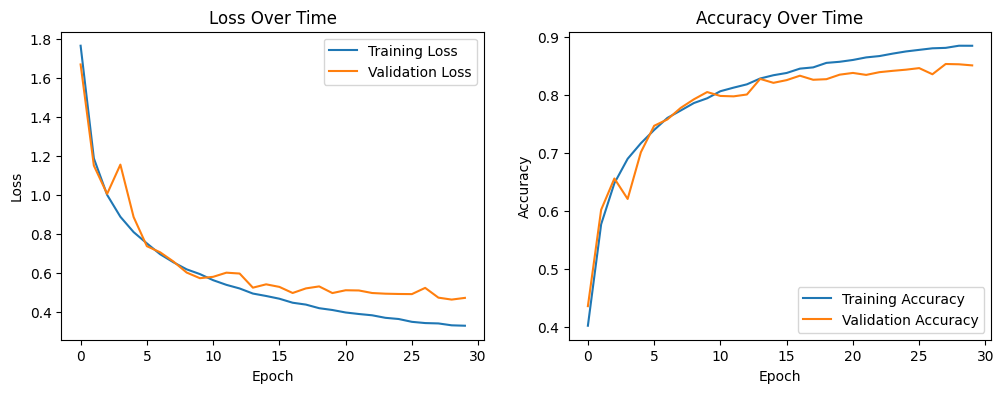

In [36]:
generate_plot(result)

In [37]:
cnn_object_classifier_model_v2.load_weights(f'{CKPT_PATH}/cnn_object_classifier_v2.keras')
test_loss_CIFAR, test_acc_CIFAR = cnn_object_classifier_model_v2.evaluate(test_ds_CIFAR)
print(f"Test Accuracy: {test_acc_CIFAR * 100:.2f}%")

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8582 - loss: 0.4623
Test Accuracy: 85.30%


(5, 32, 32, 3)
(5, 1)


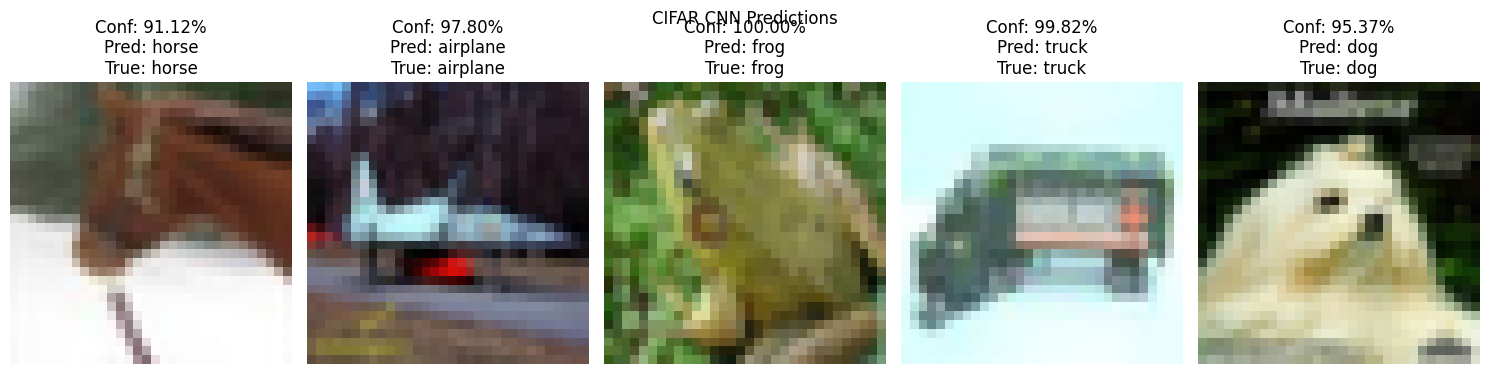

In [39]:
cnn_object_classifier_inference_model_v2=keras.models.load_model(f"{CKPT_PATH}/cnn_object_classifier_v2.keras")

num_samples = 5
X_vis, y_true = [], []

for img, lbl in test_ds_CIFAR.unbatch().take(num_samples):
    X_vis.append(img)
    y_true.append([lbl])

X_vis = tf.stack(X_vis)
X_vis_norm = tf.cast(X_vis, tf.float32)
y_true = tf.stack(y_true)
print(X_vis.shape)
print(y_true.shape)

# Now plot
plot_predictions(
    cnn_object_classifier_inference_model_v2,
    X_vis_norm,
    X_vis.numpy(),
    y_true,
    img_shape=(32,32,3),
    class_names=CIFAR_CLASS,
    cmap=None,
    title="CIFAR CNN Predictions"
)
